# RQ5: Statistical Testing — Does AI Sentiment Differ Across Developer Groups?

**Research Question:** Do developers' stances toward AI coding tools differ significantly across experience level cohorts and employment types — and do these differences persist after correcting for multiple comparisons, and what is their practical effect size?

**Task:** Statistical Hypothesis Testing  
**Groups:** Experience buckets (0–2, 3–5, 6–10, 11+ yrs) × Employment type  
**Metrics:** AISent (AI sentiment), AIAcc (AI accuracy trust), JobSat (job satisfaction)  
**Methods:** ANOVA + Tukey HSD, Kruskal-Wallis + Mann-Whitney U + Bonferroni correction  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [77]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

AISENT_MAP = {'Very unfavorable': 1, 'Unfavorable': 2, 'Indifferent': 3,
              'Unsure': 3, 'Favorable': 4, 'Very favorable': 5}
AIACC_MAP  = {'Highly distrust': 1, 'Somewhat distrust': 2,
              'Neither trust nor distrust': 3, 'Somewhat trust': 4, 'Highly trust': 5}

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std if pooled_std > 0 else 0.0

def eta_squared(groups):
    all_vals = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((v - grand_mean)**2 for g in groups for v in g)
    return ss_between / ss_total if ss_total > 0 else 0.0

def epsilon_squared(h_stat, n):
    return (h_stat - len([1]) + 1) / (n - len([1])) if n > 1 else 0.0

print('Imports OK')

Imports OK


## 1. Data Loading

In [78]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)


## 2. Data Preparation & Group Definition

In [79]:
df['YearsCode_num'] = pd.to_numeric(df['YearsCode'], errors='coerce')
df['AISent_num']    = df['AISent'].map(AISENT_MAP)
df['AIAcc_num']     = df['AIAcc'].map(AIACC_MAP)
df['JobSat_num']    = pd.to_numeric(df['JobSat'], errors='coerce')

# Experience buckets
def exp_bucket(yc):
    if pd.isna(yc): return np.nan
    if yc <= 2:  return '0-2 yrs'
    if yc <= 5:  return '3-5 yrs'
    if yc <= 10: return '6-10 yrs'
    return '11+ yrs'

df['ExpBucket'] = df['YearsCode_num'].apply(exp_bucket)

# Employment simplification
EMP_KEEP = ['Employed, full-time', 'Independent contractor, freelancer, or self-employed', 'Student, full-time']
df_f = df[
    df['ExpBucket'].notna() &
    df['AISent_num'].notna() &
    df['AIAcc_num'].notna() &
    df['JobSat_num'].notna() &
    df['Employment'].notna()
].copy()

# Keep most common employment
df_f['Employment_grp'] = df_f['Employment'].apply(
    lambda x: ('Employed' if 'Employed, full-time' in str(x) else
               ('Freelancer/Contractor' if 'contractor' in str(x).lower() or 'freelancer' in str(x).lower() else
               ('Student' if 'Student' in str(x) else None)))
)
df_f = df_f[df_f['Employment_grp'].notna()].copy()

print(f'Filtered dataset: {df_f.shape[0]} rows')
print('\nExperience bucket counts:')
print(df_f['ExpBucket'].value_counts().sort_index())
print('\nEmployment group counts:')
print(df_f['Employment_grp'].value_counts())

EXP_ORDER = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11+ yrs']
EMP_ORDER = ['Employed', 'Freelancer/Contractor', 'Student']
METRICS   = ['AISent_num', 'AIAcc_num', 'JobSat_num']
METRIC_LABELS = {'AISent_num': 'AI Sentiment', 'AIAcc_num': 'AI Trust (Accuracy)', 'JobSat_num': 'Job Satisfaction'}

Filtered dataset: 4248 rows

Experience bucket counts:
ExpBucket
0-2 yrs       60
11+ yrs     2879
3-5 yrs      419
6-10 yrs     890
Name: count, dtype: int64

Employment group counts:
Employment_grp
Freelancer/Contractor    3584
Student                   664
Name: count, dtype: int64


## 3. Violin Plots

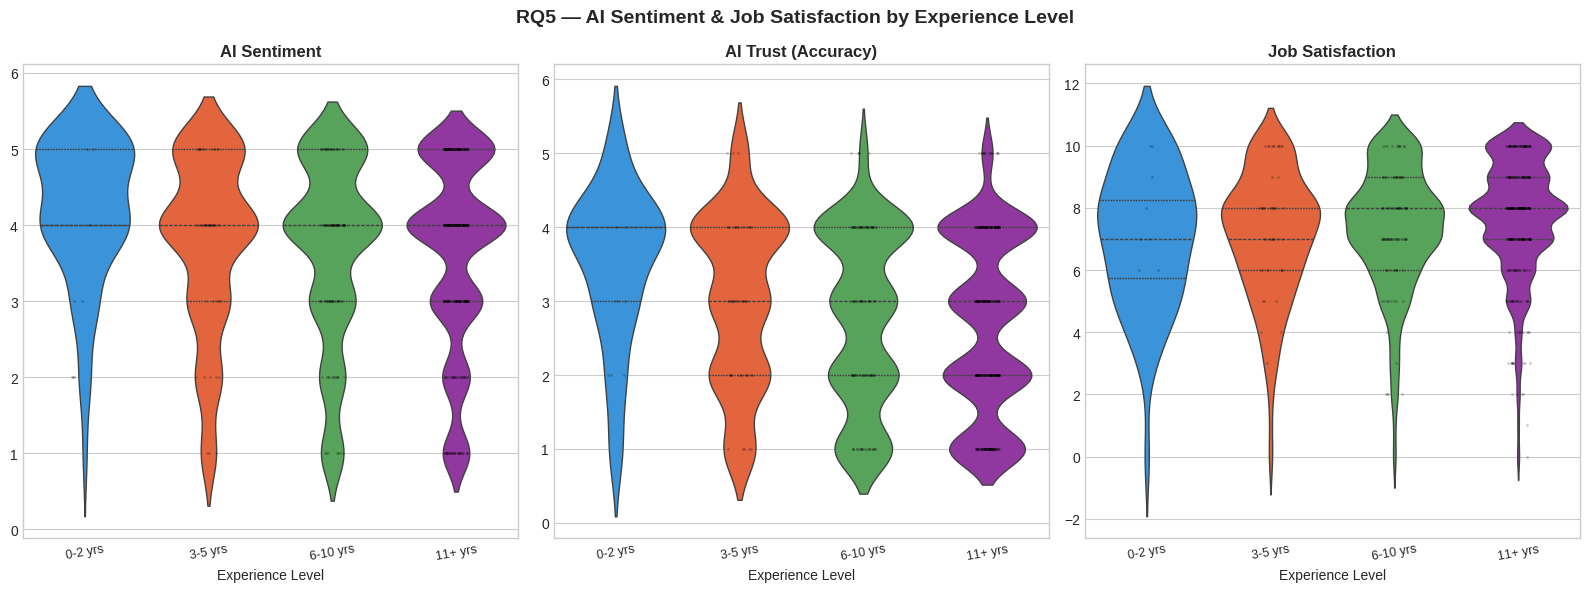

Saved figure: /kaggle/working/rq5_violin_plots_experience.pdf


In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, metric in zip(axes, METRICS):
    sns.violinplot(data=df_f, x='ExpBucket', y=metric, ax=ax,
                   order=EXP_ORDER, palette=PALETTE[:4], inner='quartile', linewidth=1)
    # Strip overlay (sample 500 points)
    sample = df_f.sample(min(500, len(df_f)), random_state=RANDOM_STATE)
    sns.stripplot(data=sample, x='ExpBucket', y=metric, ax=ax,
                  order=EXP_ORDER, color='black', alpha=0.2, size=2, jitter=True)
    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight='bold')
    ax.set_xlabel('Experience Level', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9, rotation=10)

fig.suptitle('RQ5 — AI Sentiment & Job Satisfaction by Experience Level', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq5_violin_plots_experience.pdf')
plt.show()

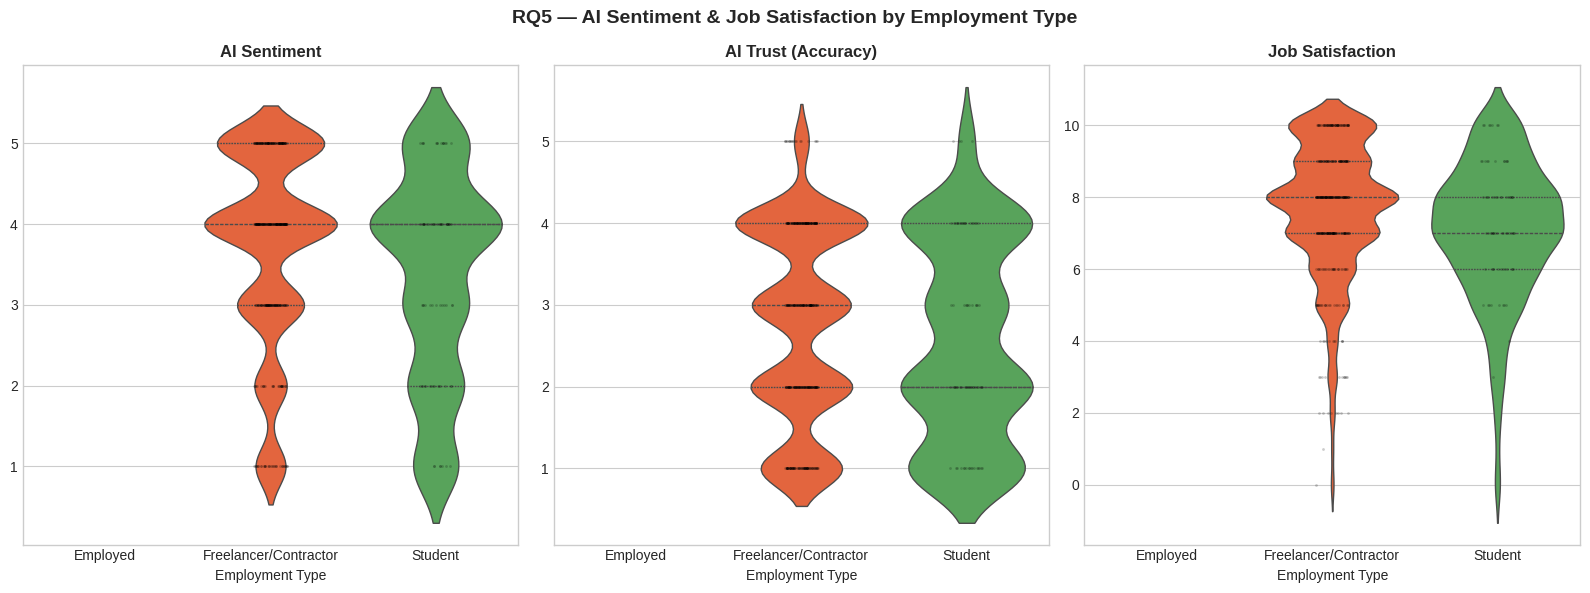

Saved figure: /kaggle/working/rq5_violin_plots_employment.pdf


In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, metric in zip(axes, METRICS):
    sns.violinplot(data=df_f, x='Employment_grp', y=metric, ax=ax,
                   order=EMP_ORDER, palette=PALETTE[:3], inner='quartile', linewidth=1)
    sample = df_f.sample(min(500, len(df_f)), random_state=RANDOM_STATE)
    sns.stripplot(data=sample, x='Employment_grp', y=metric, ax=ax,
                  order=EMP_ORDER, color='black', alpha=0.2, size=2, jitter=True)
    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight='bold')
    ax.set_xlabel('Employment Type', fontsize=10)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=10)

fig.suptitle('RQ5 — AI Sentiment & Job Satisfaction by Employment Type', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq5_violin_plots_employment.pdf')
plt.show()

## 4. Statistical Tests

In [82]:
desc_rows    = []
posthoc_rows = []
pvalue_matrices = {}  # for heatmap

group_configs = [
    ('Experience', 'ExpBucket',      EXP_ORDER),
    ('Employment', 'Employment_grp', EMP_ORDER)
]

for gvar_label, gvar_col, gvar_order in group_configs:
    for metric in METRICS:
        # Build (name, values) pairs and filter out small groups together
        named_groups = [
            (g, df_f[df_f[gvar_col] == g][metric].dropna().values)
            for g in gvar_order
        ]
        named_groups = [(name, vals) for name, vals in named_groups if len(vals) >= 5]

        if len(named_groups) < 2:
            continue

        group_names = [ng[0] for ng in named_groups]
        groups      = [ng[1] for ng in named_groups]

        # Descriptive stats
        for g_name, g_vals in named_groups:
            desc_rows.append({
                'Group_Variable': gvar_label, 'Group': g_name, 'Metric': metric,
                'Mean':   round(g_vals.mean(), 4), 'Std':    round(g_vals.std(), 4),
                'Median': round(np.median(g_vals), 4),
                'Min':    round(g_vals.min(), 4),   'Max':    round(g_vals.max(), 4),
                'Count':  len(g_vals)
            })

        # ANOVA
        f_stat, f_pval = stats.f_oneway(*groups)
        eta2 = eta_squared(groups)

        # Kruskal-Wallis
        h_stat, h_pval = stats.kruskal(*groups)
        n_total = sum(len(g) for g in groups)
        k = len(groups)
        eps2 = (h_stat - k + 1) / (n_total - k) if n_total > k else 0.0

        # Pairwise Mann-Whitney U with Bonferroni
        # Use range(len(groups)) — the filtered list, not the full gvar_order
        pairs   = list(combinations(range(len(groups)), 2))
        n_pairs = len(pairs)

        pmat_key = (gvar_label, metric)
        pmat = pd.DataFrame(np.ones((len(group_names), len(group_names))),
                            index=group_names, columns=group_names)

        for i, j in pairs:
            g1, g2 = groups[i], groups[j]
            u_stat, p_raw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            p_bonf = min(p_raw * n_pairs, 1.0)
            d = cohens_d(pd.Series(g1), pd.Series(g2))

            posthoc_rows.append({
                'Group_Variable': gvar_label, 'Metric': metric,
                'Group_A':        group_names[i], 'Group_B': group_names[j],
                'U_stat':         round(u_stat, 2), 'p_raw': round(p_raw, 6),
                'p_bonferroni':   round(p_bonf, 6), 'Significant': p_bonf < 0.05,
                'Cohens_d':       round(d, 4),
                'F_stat':         round(f_stat, 4), 'H_stat': round(h_stat, 4),
                'Eta_squared':    round(eta2, 4),   'Eps_squared': round(eps2, 4)
            })
            pmat.loc[group_names[i], group_names[j]] = p_bonf
            pmat.loc[group_names[j], group_names[i]] = p_bonf

        pvalue_matrices[pmat_key] = pmat

desc_df    = pd.DataFrame(desc_rows)
posthoc_df = pd.DataFrame(posthoc_rows)

save_table(desc_df,    'rq5_descriptive_stats.csv')
save_table(posthoc_df, 'rq5_posthoc_pairwise_tests.csv')
print(f'Descriptive stats: {desc_df.shape}')
print(f'Post-hoc tests:    {posthoc_df.shape}')

Saved table:  /kaggle/working/rq5_descriptive_stats.csv
Saved table:  /kaggle/working/rq5_posthoc_pairwise_tests.csv
Descriptive stats: (18, 9)
Post-hoc tests:    (21, 13)


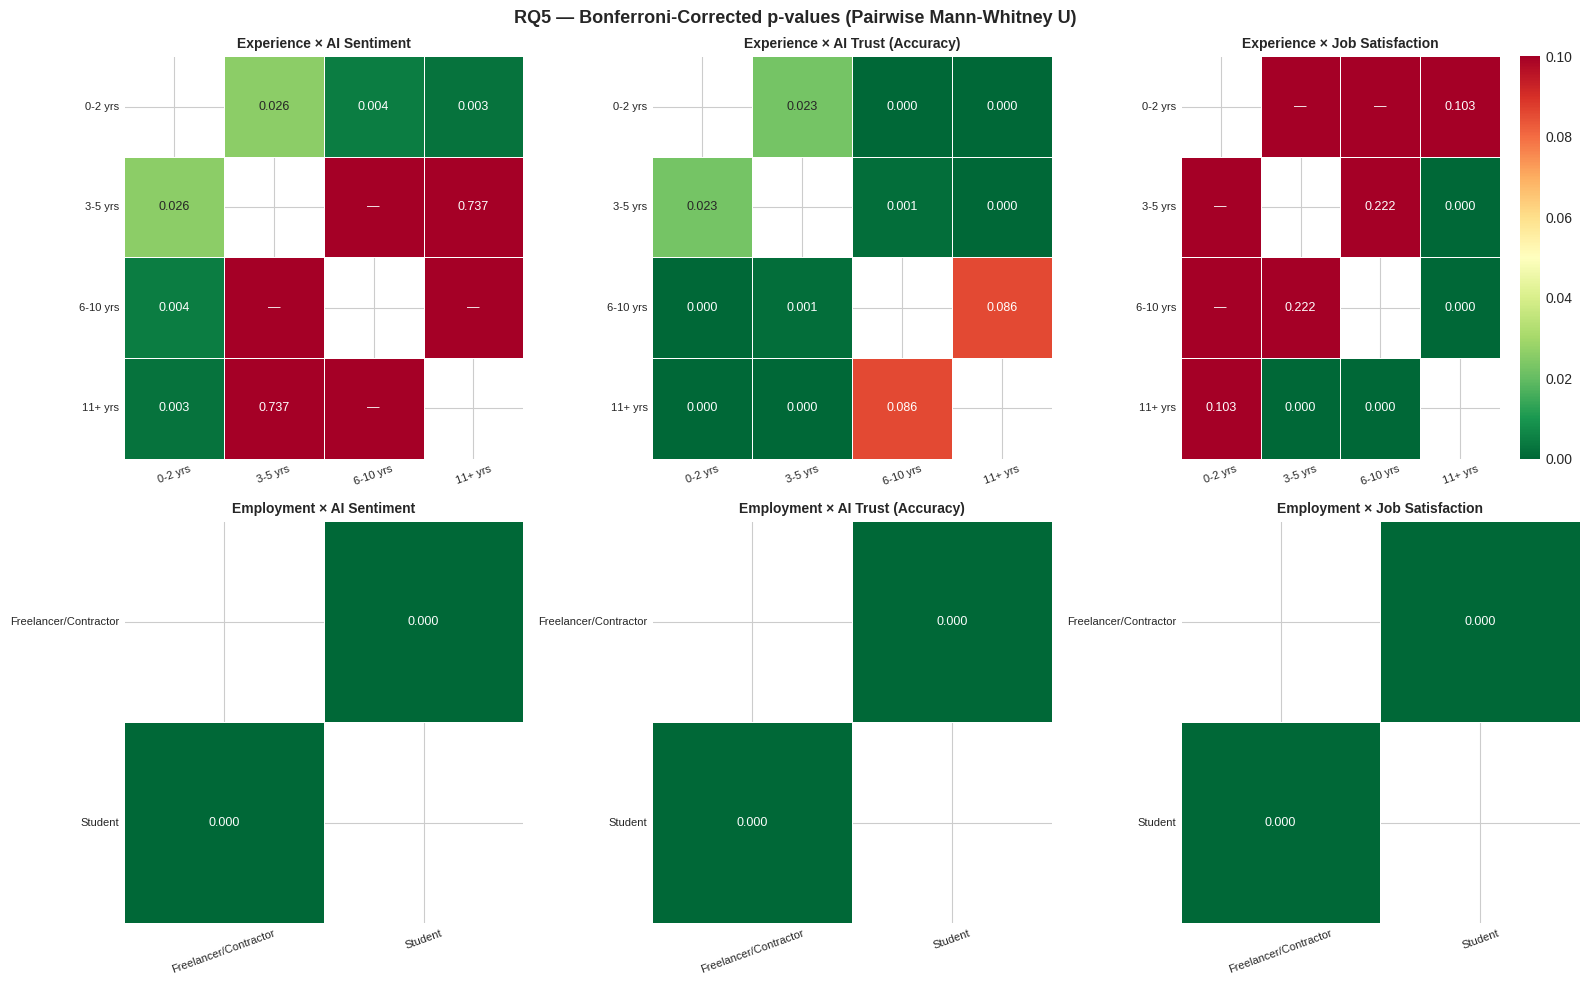

Saved figure: /kaggle/working/rq5_posthoc_pvalue_heatmap.pdf


In [83]:
# P-value heatmap grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
row_labels = ['Experience', 'Employment']

for row_idx, gvar_label in enumerate(['Experience', 'Employment']):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        key = (gvar_label, metric)
        if key not in pvalue_matrices:
            ax.set_visible(False)
            continue
        pmat = pvalue_matrices[key]
        mask = np.eye(len(pmat), dtype=bool)
        annot_vals = pmat.copy()
        annot_text = annot_vals.applymap(lambda v: f'{v:.3f}' if v < 1.0 else '—')
        sns.heatmap(pmat, ax=ax, annot=annot_text, fmt='', cmap='RdYlGn_r',
                    vmin=0, vmax=0.1, mask=mask, linewidths=0.5,
                    cbar=row_idx == 0 and col_idx == 2,
                    annot_kws={'size': 9})
        ax.set_title(f'{gvar_label} × {METRIC_LABELS[metric]}', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=8, rotation=20)
        ax.tick_params(axis='y', labelsize=8, rotation=0)

fig.suptitle('RQ5 — Bonferroni-Corrected p-values (Pairwise Mann-Whitney U)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq5_posthoc_pvalue_heatmap.pdf')
plt.show()

## 5. Conclusions

In [84]:
n_sig = posthoc_df['Significant'].sum()
n_total_pairs = len(posthoc_df)
print('=' * 60)
print('RQ5 CONCLUSION')
print('=' * 60)
print(f'Total pairwise comparisons tested: {n_total_pairs}')
print(f'Significant after Bonferroni correction: {n_sig} ({n_sig/n_total_pairs*100:.1f}%)')
print()
print('Largest effect sizes (|Cohen\'s d|):')
top_effects = posthoc_df.reindex(posthoc_df['Cohens_d'].abs().nlargest(5).index)
for _, row in top_effects.iterrows():
    print(f'  {row["Group_Variable"]} | {row["Metric"]}: {row["Group_A"]} vs {row["Group_B"]} '
          f'| d={row["Cohens_d"]:.3f}, p_bonf={row["p_bonferroni"]:.4f}')
print()
print('Output files saved to /kaggle/working/:')
print('  rq5_violin_plots_experience.pdf')
print('  rq5_violin_plots_employment.pdf')
print('  rq5_posthoc_pvalue_heatmap.pdf')
print('  rq5_descriptive_stats.csv')
print('  rq5_posthoc_pairwise_tests.csv')

RQ5 CONCLUSION
Total pairwise comparisons tested: 21
Significant after Bonferroni correction: 13 (61.9%)

Largest effect sizes (|Cohen's d|):
  Experience | AIAcc_num: 0-2 yrs vs 11+ yrs | d=0.695, p_bonf=0.0000
  Experience | AIAcc_num: 0-2 yrs vs 6-10 yrs | d=0.613, p_bonf=0.0000
  Experience | AISent_num: 0-2 yrs vs 11+ yrs | d=0.451, p_bonf=0.0027
  Experience | AISent_num: 0-2 yrs vs 6-10 yrs | d=0.443, p_bonf=0.0044
  Experience | AIAcc_num: 0-2 yrs vs 3-5 yrs | d=0.394, p_bonf=0.0226

Output files saved to /kaggle/working/:
  rq5_violin_plots_experience.pdf
  rq5_violin_plots_employment.pdf
  rq5_posthoc_pvalue_heatmap.pdf
  rq5_descriptive_stats.csv
  rq5_posthoc_pairwise_tests.csv
